# Implementasi K-Means Clustering

Notebook ini mendemonstrasikan implementasi K-Means clustering dengan:
1. Mall Customers dataset (customer segmentation)
2. Elbow Method untuk menentukan k optimal
3. Silhouette Analysis
4. Visualisasi hasil clustering
5. Perbandingan dengan Hierarchical Clustering

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset

In [2]:
# Load Mall Customers datasetdf = pd.read_csv('../datasets/Mall_Customers (2).csv')# Rename columnsdf.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']print("Dataset Shape:", df.shape)print("\nFirst 5 rows:")display(df.head())print("\nDataset Info:")df.info()print("\nStatistik Deskriptif:")display(df.describe())

Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      200 non-null    int64 
 1   Gender          200 non-null    object
 2   Age             200 non-null    int64 
 3   Annual_Income   200 non-null    int64 
 4   Spending_Score  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Statistik Deskriptif:


,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. Exploratory Data Analysis

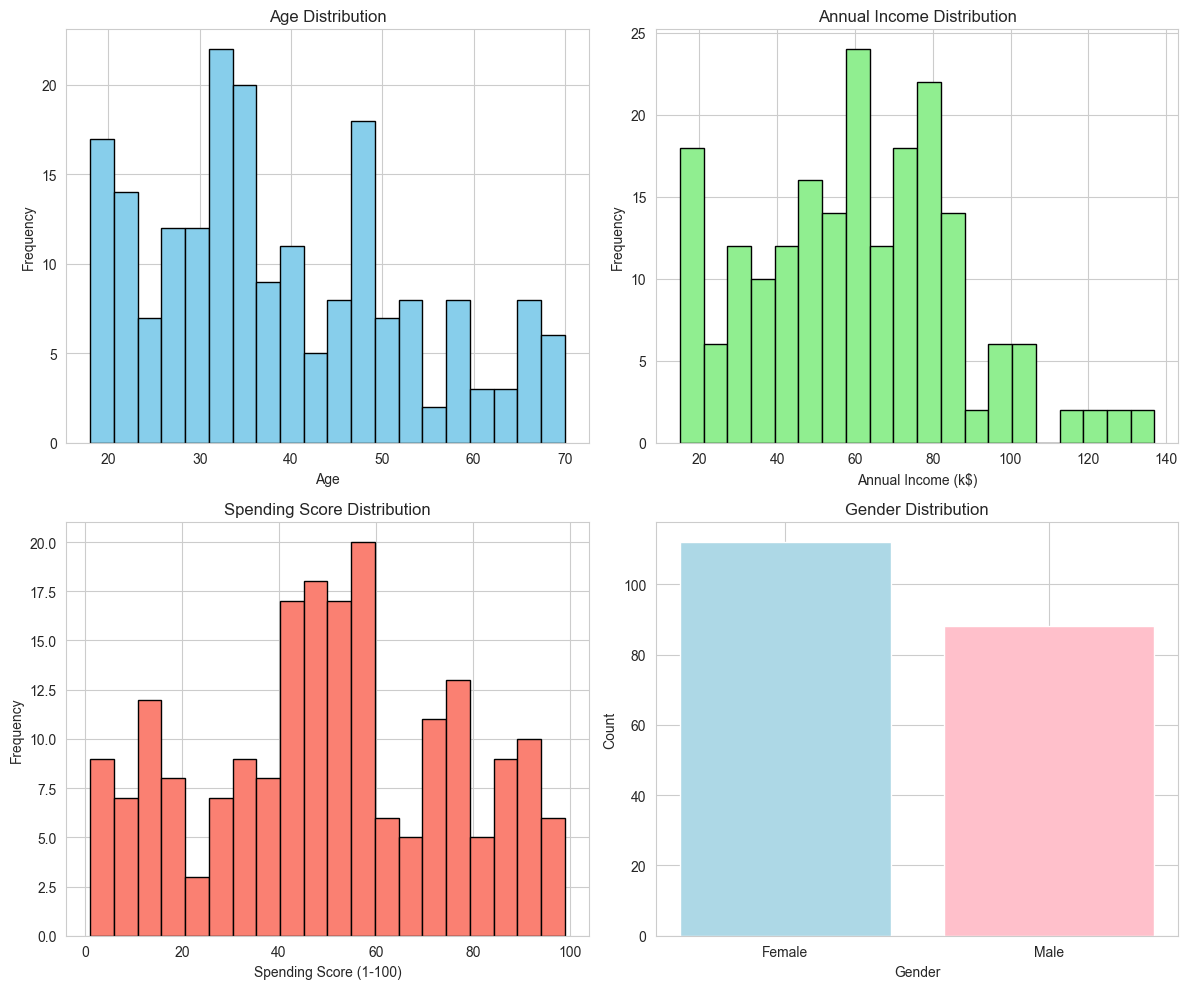

In [3]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Age distribution
axes[0, 0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Annual Income distribution
axes[0, 1].hist(df['Annual_Income'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Annual Income Distribution')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Frequency')

# Spending Score distribution
axes[1, 0].hist(df['Spending_Score'], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title('Spending Score Distribution')
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Frequency')

# Gender distribution
gender_counts = df['Gender'].value_counts()
axes[1, 1].bar(gender_counts.index, gender_counts.values, color=['lightblue', 'pink'])
axes[1, 1].set_title('Gender Distribution')
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

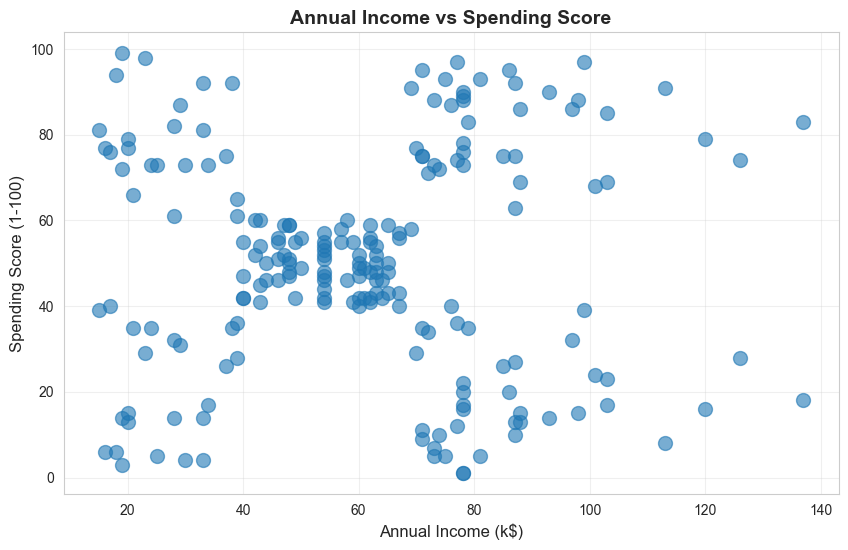

Visual inspection suggests 4-5 natural clusters


In [4]:
# Scatter plot: Annual Income vs Spending Score
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], alpha=0.6, s=100)
plt.title('Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("Visual inspection suggests 4-5 natural clusters")

## 4. Data Preprocessing

In [5]:
# Select features for clustering
X = df[['Annual_Income', 'Spending_Score']].values

print("Features shape:", X.shape)
print("\nBefore Standardization:")
print(f"Annual Income - Mean: {X[:, 0].mean():.2f}, Std: {X[:, 0].std():.2f}")
print(f"Spending Score - Mean: {X[:, 1].mean():.2f}, Std: {X[:, 1].std():.2f}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter Standardization:")
print(f"Annual Income - Mean: {X_scaled[:, 0].mean():.2f}, Std: {X_scaled[:, 0].std():.2f}")
print(f"Spending Score - Mean: {X_scaled[:, 1].mean():.2f}, Std: {X_scaled[:, 1].std():.2f}")

Features shape: (200, 2)

Before Standardization:
Annual Income - Mean: 60.56, Std: 26.20
Spending Score - Mean: 50.20, Std: 25.76

After Standardization:
Annual Income - Mean: -0.00, Std: 1.00
Spending Score - Mean: -0.00, Std: 1.00


## 5. Elbow Method - Menentukan k Optimal

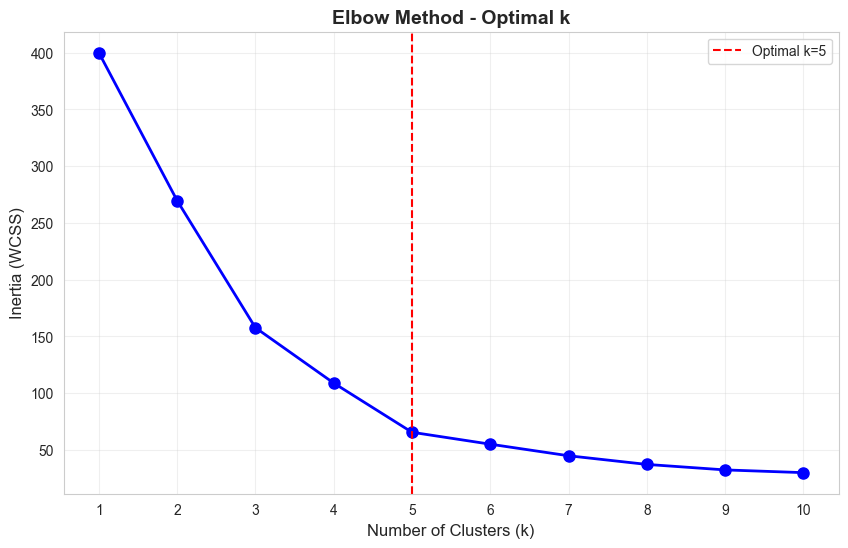


Inertia values:
k=1: Inertia = 400.00
k=2: Inertia = 269.69
k=3: Inertia = 157.70
k=4: Inertia = 108.92
k=5: Inertia = 65.57
k=6: Inertia = 55.06
k=7: Inertia = 44.86
k=8: Inertia = 37.23
k=9: Inertia = 32.39
k=10: Inertia = 29.98


In [6]:
# Calculate inertia for different k values
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='r', linestyle='--', label='Optimal k=5')
plt.title('Elbow Method - Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nInertia values:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: Inertia = {inertia:.2f}")

## 6. Silhouette Analysis

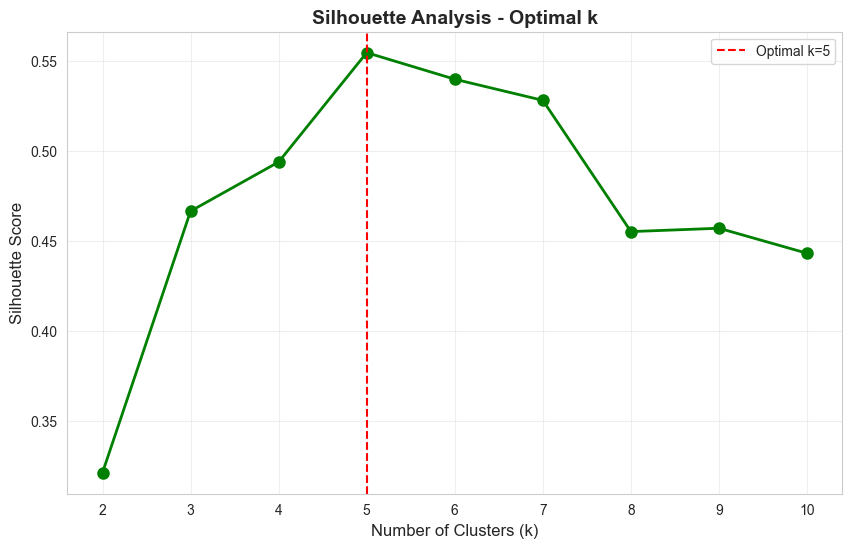


Silhouette Scores:
k=2: Silhouette Score = 0.321
k=3: Silhouette Score = 0.467
k=4: Silhouette Score = 0.494
k=5: Silhouette Score = 0.555
k=6: Silhouette Score = 0.540
k=7: Silhouette Score = 0.528
k=8: Silhouette Score = 0.455
k=9: Silhouette Score = 0.457
k=10: Silhouette Score = 0.443

Optimal k by Silhouette: 5


In [7]:
# Calculate silhouette scores for different k values
silhouette_scores = []
K_range_sil = range(2, 11)  # Silhouette requires at least 2 clusters

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_scores, 'go-', linewidth=2, markersize=8)
optimal_k = K_range_sil[np.argmax(silhouette_scores)]
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
plt.title('Silhouette Analysis - Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(K_range_sil)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(K_range_sil, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.3f}")

print(f"\nOptimal k by Silhouette: {optimal_k}")

## 7. K-Means Clustering dengan k Optimal

In [8]:
# Apply K-Means with optimal k
optimal_k = 5  # Based on Elbow method

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Get centroids (in original scale)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

print(f"K-Means with k={optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Iterations: {kmeans.n_iter_}")
print(f"\nSilhouette Score: {silhouette_score(X_scaled, df['Cluster']):.3f}")

print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

print("\nCentroids (original scale):")
centroids_df = pd.DataFrame(centroids, columns=['Annual_Income', 'Spending_Score'])
centroids_df.index.name = 'Cluster'
display(centroids_df)

K-Means with k=5
Inertia: 65.57
Iterations: 4

Silhouette Score: 0.555

Cluster Sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Centroids (original scale):


,Annual_Income,Spending_Score
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## 8. Visualisasi Hasil Clustering

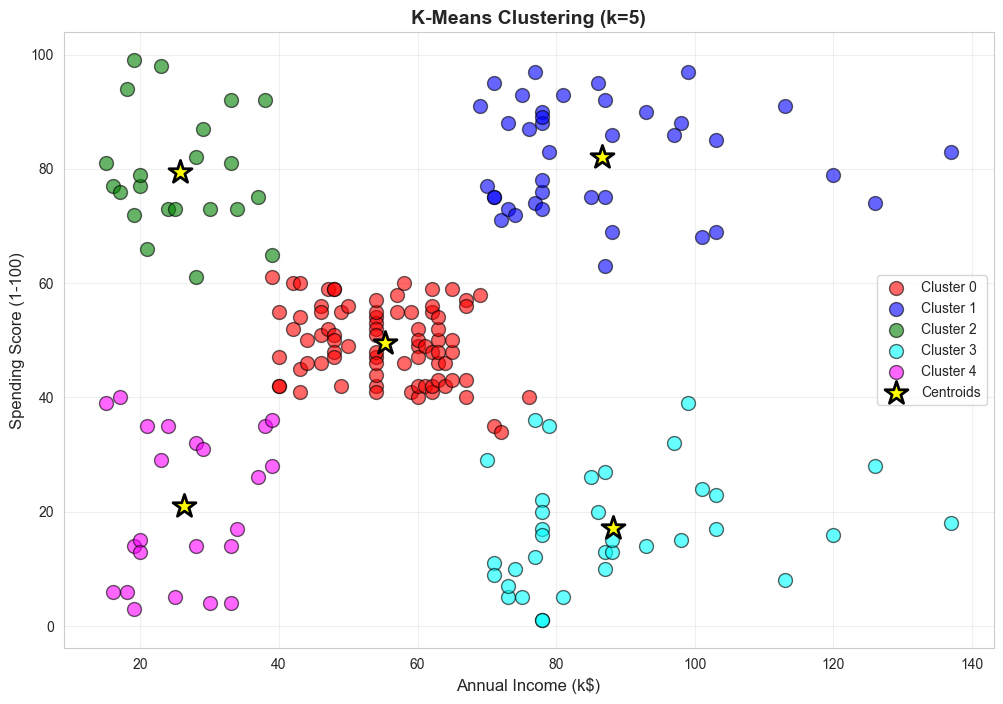

In [9]:
# Scatter plot with clusters
plt.figure(figsize=(12, 8))

# Plot each cluster with different color
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income'], 
                cluster_data['Spending_Score'],
                s=100, c=colors[i], label=f'Cluster {i}', alpha=0.6, edgecolors='black')

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=300, c='yellow', marker='*', edgecolors='black', linewidths=2,
            label='Centroids')

plt.title(f'K-Means Clustering (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Interpretasi Cluster

In [10]:
# Analyze cluster characteristics
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()
cluster_summary['Count'] = df.groupby('Cluster').size()

print("Cluster Characteristics:")
display(cluster_summary)

# Interpretasi manual
interpretations = {
    0: "Careful Customers (Low Income, Low Spending)",
    1: "Standard Customers (Medium Income, Medium Spending)",
    2: "Target Customers (Medium Income, High Spending)",
    3: "Careless Customers (High Income, High Spending)",
    4: "Sensible Customers (High Income, Low Spending)"
}

print("\nCluster Interpretations:")
for cluster, interpretation in interpretations.items():
    print(f"Cluster {cluster}: {interpretation}")

Cluster Characteristics:


,Age,Annual_Income,Spending_Score,Count
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23



Cluster Interpretations:
Cluster 0: Careful Customers (Low Income, Low Spending)
Cluster 1: Standard Customers (Medium Income, Medium Spending)
Cluster 2: Target Customers (Medium Income, High Spending)
Cluster 3: Careless Customers (High Income, High Spending)
Cluster 4: Sensible Customers (High Income, Low Spending)


## 10. Silhouette Plot Detail

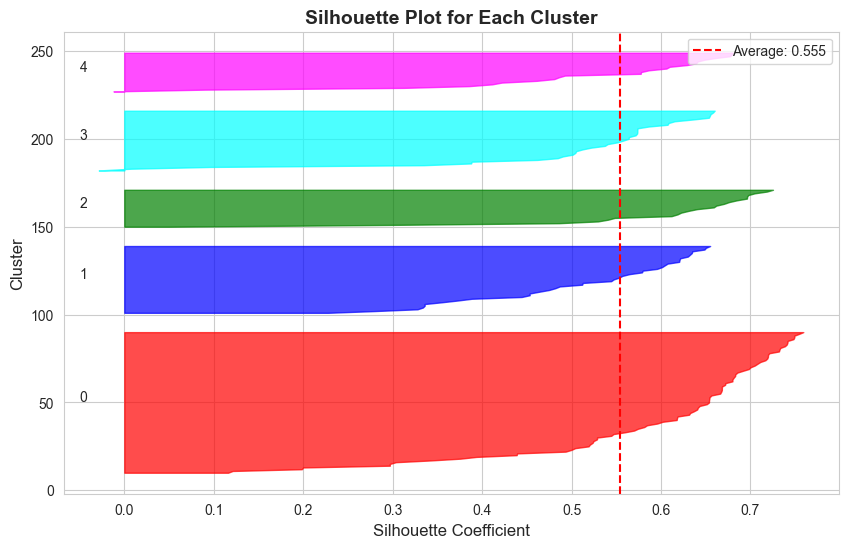

In [11]:
# Detailed silhouette plot
silhouette_vals = silhouette_samples(X_scaled, df['Cluster'])

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[df['Cluster'] == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

# Average silhouette score
avg_score = silhouette_score(X_scaled, df['Cluster'])
ax.axvline(x=avg_score, color="red", linestyle="--", label=f'Average: {avg_score:.3f}')

ax.set_title('Silhouette Plot for Each Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.legend()
plt.show()

## 11. Perbandingan dengan Hierarchical Clustering

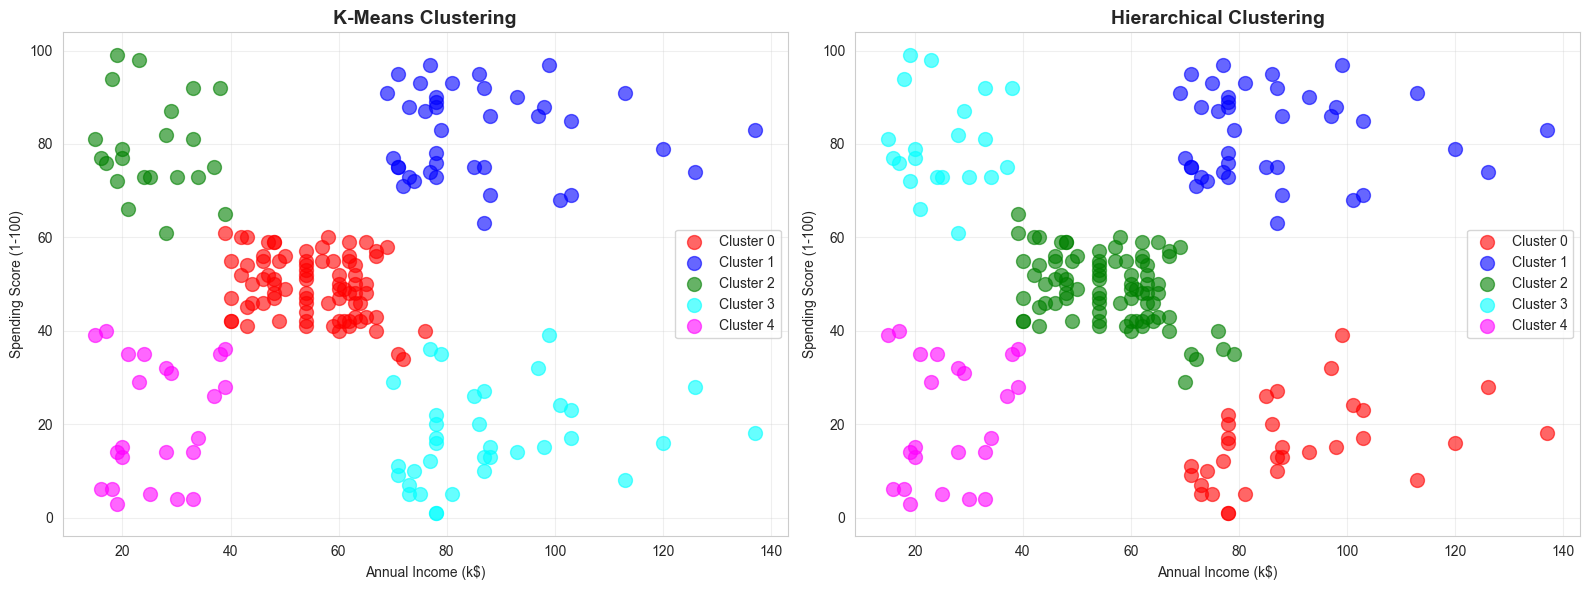


Silhouette Score Comparison:
K-Means: 0.555
Hierarchical: 0.554

Winner: K-Means


In [12]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
df['Hierarchical_Cluster'] = hierarchical.fit_predict(X_scaled)

# Compare results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    axes[0].scatter(cluster_data['Annual_Income'], 
                    cluster_data['Spending_Score'],
                    s=100, c=colors[i], label=f'Cluster {i}', alpha=0.6)
axes[0].set_title('K-Means Clustering', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hierarchical
for i in range(optimal_k):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    axes[1].scatter(cluster_data['Annual_Income'], 
                    cluster_data['Spending_Score'],
                    s=100, c=colors[i], label=f'Cluster {i}', alpha=0.6)
axes[1].set_title('Hierarchical Clustering', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare silhouette scores
kmeans_sil = silhouette_score(X_scaled, df['Cluster'])
hierarchical_sil = silhouette_score(X_scaled, df['Hierarchical_Cluster'])

print("\nSilhouette Score Comparison:")
print(f"K-Means: {kmeans_sil:.3f}")
print(f"Hierarchical: {hierarchical_sil:.3f}")
print(f"\nWinner: {'K-Means' if kmeans_sil > hierarchical_sil else 'Hierarchical'}")

## 12. Dendrogram (Hierarchical)

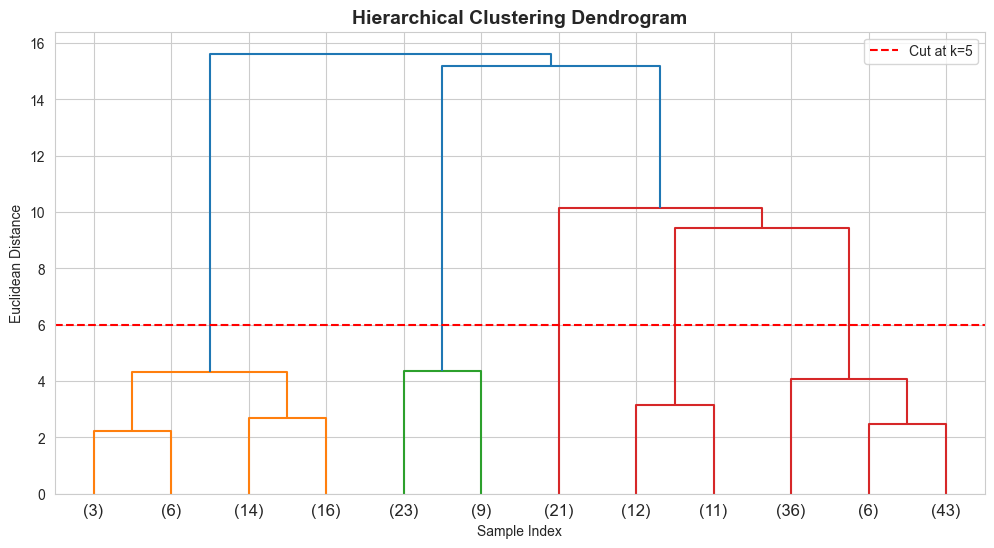

In [13]:
# Create dendrogram
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=12, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=6, color='r', linestyle='--', label='Cut at k=5')
plt.legend()
plt.show()

## 13. Kesimpulan

### Hasil K-Means Clustering:
1. **Optimal k = 5** (berdasarkan Elbow Method)
2. **5 Customer Segments** teridentifikasi dengan jelas
3. **Silhouette Score** menunjukkan cluster separation yang baik

### Customer Segments:
- **Cluster 0**: Careful Customers (Low Income, Low Spending)
- **Cluster 1**: Standard Customers (Medium Income, Medium Spending)
- **Cluster 2**: Target Customers (Medium Income, High Spending)
- **Cluster 3**: Careless Customers (High Income, High Spending)
- **Cluster 4**: Sensible Customers (High Income, Low Spending)

### Business Recommendations:
- **Cluster 2 & 3**: Focus marketing efforts (high spending potential)
- **Cluster 4**: Upselling opportunities (high income, low spending)
- **Cluster 0**: Budget-friendly products
- **Cluster 1**: Standard offerings

### K-Means vs Hierarchical:
- K-Means lebih cepat dan scalable
- Hierarchical memberikan dendrogram untuk exploratory analysis
- Hasil clustering serupa untuk dataset ini

---
## Simple Visualization: Before vs After Clustering
## Visualisasi Sederhana: Sebelum vs Sesudah Clustering

Contoh sederhana menggunakan dataset ideal (Regular Blobs).

WITHOUT Scaling: Silhouette = 0.608 (Poor clustering)
WITH Scaling: Silhouette = 0.699 (Good clustering)

Lesson: Always standardize features before K-Means!
Pelajaran: Selalu standardisasi fitur sebelum K-Means!


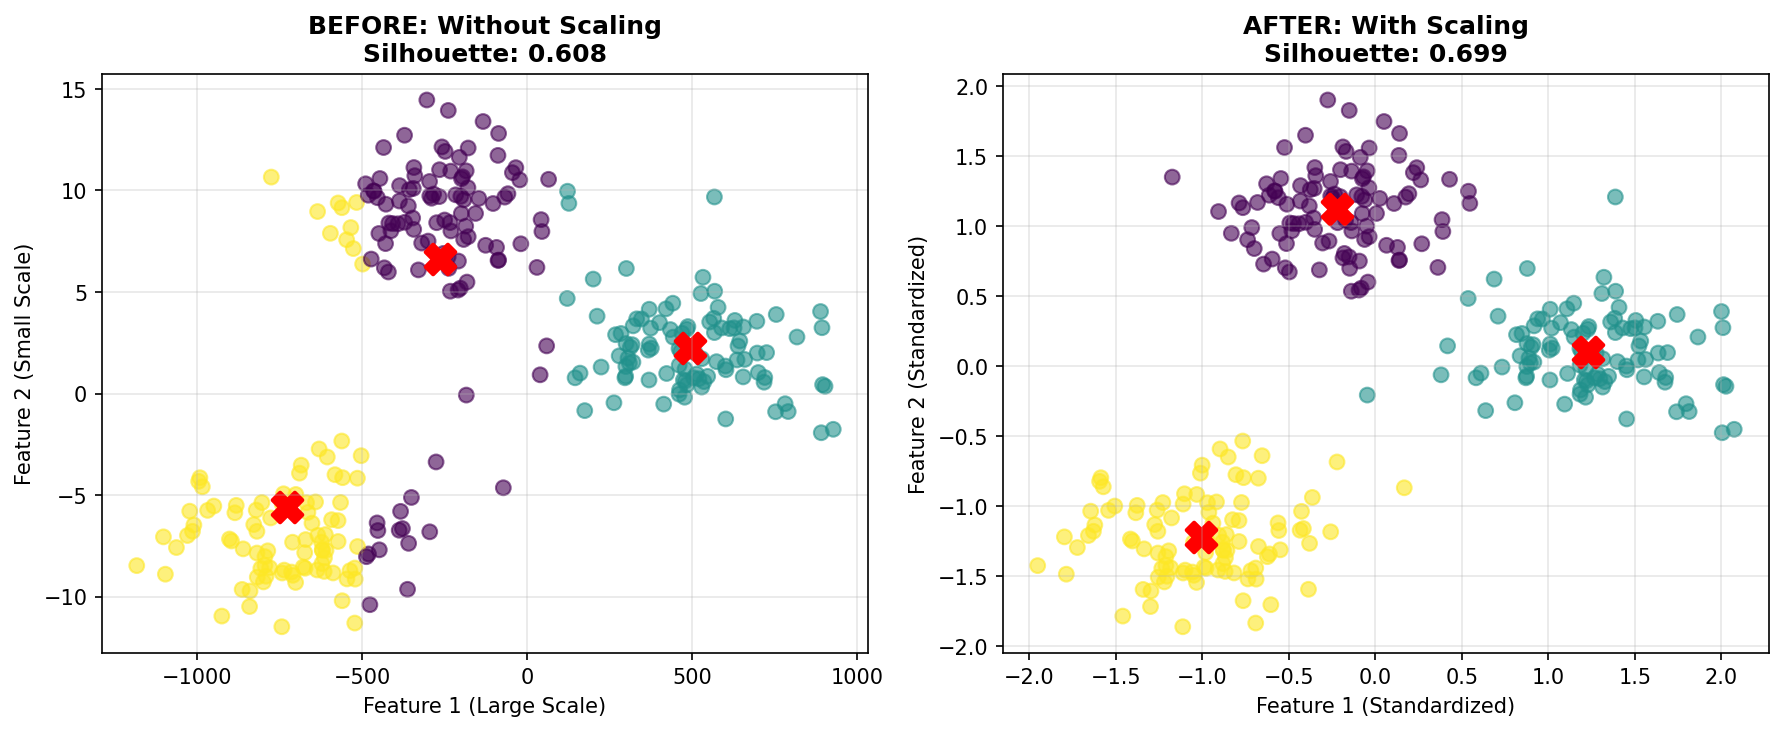

In [15]:
# Generate same dataset - compare with/without scaling
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Generate dataset with different scales
X_raw, y_true = make_blobs(n_samples=300, centers=3, 
                           center_box=(-10, 10), cluster_std=2.0, random_state=42)
# Make features have very different scales
X_raw[:, 0] = X_raw[:, 0] * 100  # Feature 1: large scale
X_raw[:, 1] = X_raw[:, 1] * 1    # Feature 2: small scale

# Without scaling (BEFORE)
kmeans_unscaled = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_unscaled = kmeans_unscaled.fit_predict(X_raw)
sil_unscaled = silhouette_score(X_raw, y_pred_unscaled)

# With scaling (AFTER)
X_scaled = StandardScaler().fit_transform(X_raw)
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_scaled = kmeans_scaled.fit_predict(X_scaled)
sil_scaled = silhouette_score(X_scaled, y_pred_scaled)

# Create before/after visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before: Without scaling (FAILS)
ax1.scatter(X_raw[:, 0], X_raw[:, 1], c=y_pred_unscaled, cmap='viridis', s=50, alpha=0.6)
ax1.scatter(kmeans_unscaled.cluster_centers_[:, 0], kmeans_unscaled.cluster_centers_[:, 1], 
           c='red', marker='X', s=200, linewidths=2)
ax1.set_title(f'BEFORE: Without Scaling\nSilhouette: {sil_unscaled:.3f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature 1 (Large Scale)')
ax1.set_ylabel('Feature 2 (Small Scale)')
ax1.grid(True, alpha=0.3)

# After: With scaling (SUCCESS)
ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred_scaled, cmap='viridis', s=50, alpha=0.6)
ax2.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1], 
           c='red', marker='X', s=200, linewidths=2)
ax2.set_title(f'AFTER: With Scaling\nSilhouette: {sil_scaled:.3f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1 (Standardized)')
ax2.set_ylabel('Feature 2 (Standardized)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"WITHOUT Scaling: Silhouette = {sil_unscaled:.3f} (Poor clustering)")
print(f"WITH Scaling: Silhouette = {sil_scaled:.3f} (Good clustering)")
print("\nLesson: Always standardize features before K-Means!")
print("Pelajaran: Selalu standardisasi fitur sebelum K-Means!")